# HW1
## TODO:  Your ID goes here: 209176510, 318477932, 207691676

#### TODO: You emails for here: argas@post.bgu.ac.il, Gochman@post.bgu.ac.il, itaipo@post.bgu.ac.il

## Introduction
This is the first Deep Learning assignment of the course.
It is divided into three sections:
1. Toy classification tasks (50 pts.)
2. Toy regressions tasks (30 pts.)
3. MNIST (binary) classification task (20 pts.)

See the instructions before each section.
You are not required to normalize the data in sections 1 and 2.

## Submission
The deadline for the task is 12.12.2024 end of day.
You may work in teams of 2 or 3.

Submission is via Moodle. Submit the **already run** notebook (i.e., with its output, figures, etc.,).

#Section 1: Classification Tasks
## TODO
For the entire section, do the following (i.e., only once):
1. Write a training function that returns the trained model and training loss
2. Write a plotting function to plot the training loss
3. Write a plotting function that scatter plots the predicted labels and decision boundaries.
4. Write a preprocessing function to handle the data (convert to pytorch tensor, etc).
5. Write an evaluation function that prints the set accuracy (train/test)

For each of the 5 exercises, do the following:
1. Create either a linear classifier if the problem seems linearly separable or an MLP using PyTorch. Explain your choice.
2. Train the model and plot the loss across epochs.
3. Plot the predicted labels and decision boundaries for the train set. Show the accuracy in the title (up to 3 decimals points).
4. Plot the predicted labels and decision boundaries for the test set.  Show the accuracy in the title (up to 3 decimals points).
5. Do NOT change the random seed of the data generation functions.
6. Create a Markdown cell and explain briefly (2-3 lines): why did the model perform well/poorly? What affected your design choices? What did you learn from previous attempts?


EX5 has further instructions.

## Grading:
**Accuracy** computed on the test set:
1. 80-100%: 10 pts (full grade)
2. 70-80%: 8pts
3. 60-70%: 6pts
4. < 60%: 5pts

You will also be graded on the correctness of your code and the discussion that follows each excersice.



## Setup
## DO NOT MODIFY THESE FUNCTIONS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
### EX1
def random_points_in_triangle(v1, v2, v3, n_points):
    points = []
    for _ in range(n_points):
        r1, r2 = np.random.rand(2)
        sqrt_r1 = np.sqrt(r1)
        point = (1 - sqrt_r1) * v1 + sqrt_r1 * (1 - r2) * v2 + sqrt_r1 * r2 * v3
        points.append(point)
    return np.array(points)

def generate_symmetric_triangles_data(K=3, N=100, random_state=42):
    np.random.seed(random_state)
    # Define vertices for three symmetric triangles
    side_length = 2
    height = np.sqrt(3) * side_length / 2
    triangles = [
        (np.array([0, 0]), np.array([side_length, 0]), np.array([side_length / 2, height])),
        (np.array([0, 0]), np.array([-side_length, 0]), np.array([-side_length / 2, height])),
        (np.array([0, 0]), np.array([1.5, -height]), np.array([-1.5, -height]))
    ]

    X, y = [], []
    for i, (v1, v2, v3) in enumerate(triangles):
        points = random_points_in_triangle(v1, v2, v3, N)
        X.append(points)
        y += [i] * N

    X = np.vstack(X)
    y = np.array(y)
    return X, y

### EX2
def generate_grid_data(grid_size=4, min_points=5, max_points=20, random_state=42):
    np.random.seed(random_state)
    X, y = [], []
    half_grid_size = grid_size // 2

    for i in range(grid_size):
        for j in range(grid_size):
            n_points = np.random.randint(min_points, max_points + 1)
            x_offset = i - half_grid_size + 0.5
            y_offset = j - half_grid_size + 0.5
            # Generate points more centered within the square
            points = 0.8 * (np.random.rand(n_points, 2) - 0.5) + [x_offset, y_offset]
            X.append(points)
            label = (i + j) % 2
            y += [label] * n_points

    X = np.vstack(X)
    y = np.array(y)
    return X, y

### EX3
def generate_concentric_circles_data(radii=[1, 2, 3, 4], points_per_circle=100, random_state=42):
    np.random.seed(random_state)
    X, y = [], []

    for i, radius in enumerate(radii):
        angles = np.linspace(0, 2 * np.pi, points_per_circle, endpoint=False)
        circle_x = radius * np.cos(angles) + np.random.normal(0, 0.1, points_per_circle)
        circle_y = radius * np.sin(angles) + np.random.normal(0, 0.1, points_per_circle)
        X.append(np.vstack((circle_x, circle_y)).T)
        y += [i] * points_per_circle

    X = np.vstack(X)
    y = np.array(y)
    return X, y

### EX4
def generate_nested_rectangles_data(inner_rect=(2, 1), middle_rect=(4, 2), outer_rect=(6, 3), points_per_rectangle=100, random_state=42):
    np.random.seed(random_state)
    X, y = [], []

    # Inner rectangle
    width, height = inner_rect
    x_points = width * (np.random.rand(points_per_rectangle) - 0.5)
    y_points = height * (np.random.rand(points_per_rectangle) - 0.5)
    X.append(np.vstack((x_points, y_points)).T)
    y += [0] * points_per_rectangle

    # Middle rectangle
    width, height = middle_rect
    x_points = width * (np.random.rand(points_per_rectangle) - 0.5)
    y_points = height * (np.random.rand(points_per_rectangle) - 0.5)
    # Exclude points that fall inside the inner rectangle
    mask = (np.abs(x_points) > inner_rect[0] / 2) | (np.abs(y_points) > inner_rect[1] / 2)
    X.append(np.vstack((x_points[mask], y_points[mask])).T)
    y += [1] * len(x_points[mask])

    # Outer rectangle
    width, height = outer_rect
    x_points = width * (np.random.rand(points_per_rectangle) - 0.5)
    y_points = height * (np.random.rand(points_per_rectangle) - 0.5)
    # Exclude points that fall inside the middle rectangle
    mask = (np.abs(x_points) > middle_rect[0] / 2) | (np.abs(y_points) > middle_rect[1] / 2)
    X.append(np.vstack((x_points[mask], y_points[mask])).T)
    y += [2] * len(x_points[mask])

    X = np.vstack(X)
    y = np.array(y)
    return X, y


def plot_data(X, y, title=""):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend(handles=scatter.legend_elements()[0], labels=set(y), title="Classes")
    plt.show()



# TODO - your general functions for Section 1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
def preprocess_data(X, y, batch_size=32):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y, dtype=torch.long).to(device)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), device


In [ ]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=100):

    model.to(device)
    train_losses = []
    for epoch in tqdm(range(epochs)):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
    return model, train_losses


In [ ]:
def plot_training_loss(train_losses):

    plt.figure(figsize=(8, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid()
    plt.show()

def plot_decision_boundaries(model, X, y, device, title="Decision Boundaries"):

    model.to(device)
    model.eval()


    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]


    grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)


    with torch.no_grad():
        preds = model(grid_tensor).argmax(dim=1).cpu().numpy()


    preds = preds.reshape(xx.shape)


    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title(title)
    plt.show()




In [ ]:
def evaluate_model(model, loader, device):

    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return correct / total



## EX1

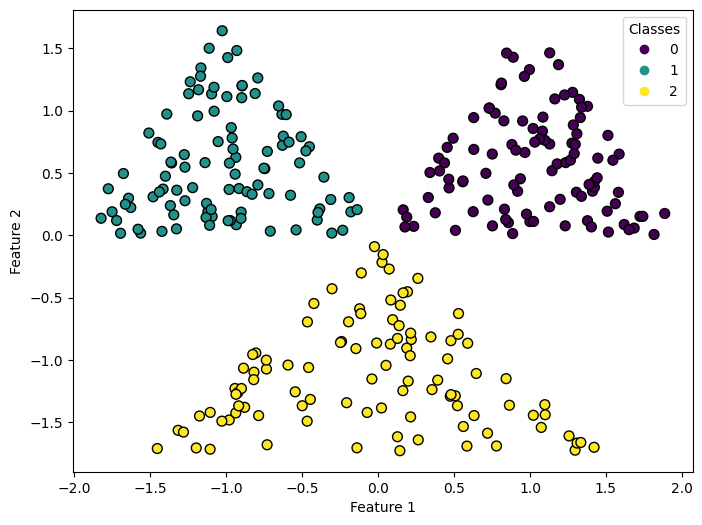

In [ ]:
# Generate the data
X_train, y_train = generate_symmetric_triangles_data(random_state=0)
X_test, y_test = generate_symmetric_triangles_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)

100%|██████████| 100/100 [00:01<00:00, 56.38it/s]


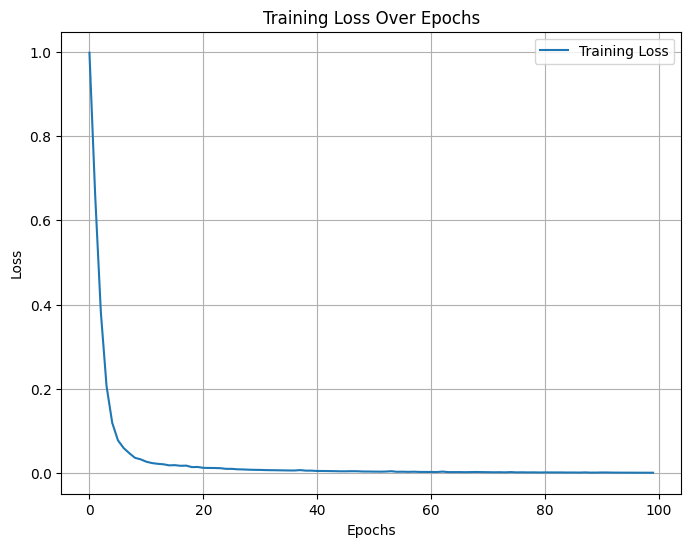

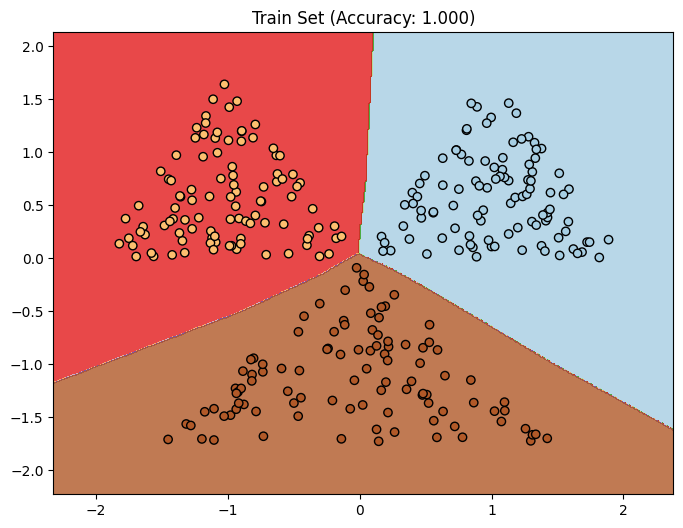

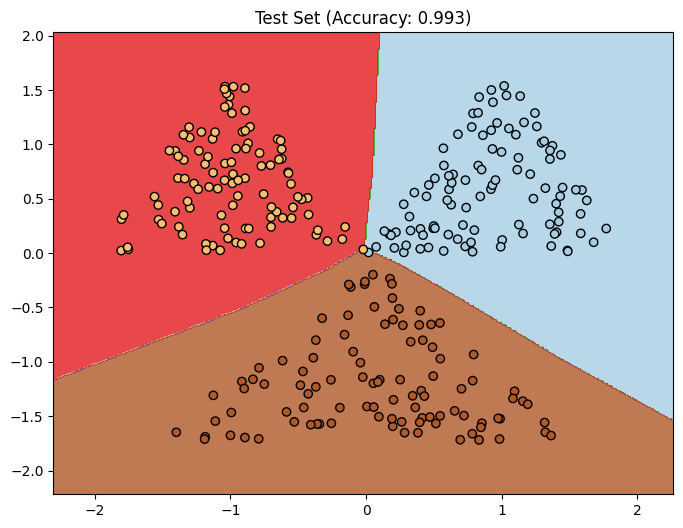

In [ ]:
### Your code goes here ####
train_loader, device = preprocess_data(X_train, y_train)
test_loader, _ = preprocess_data(X_test, y_test)

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=100)

plot_training_loss(train_losses)


train_accuracy = evaluate_model(model, train_loader, device)
plot_decision_boundaries(model, X_train, y_train, device, title=f"Train Set (Accuracy: {train_accuracy:.3f})")


test_accuracy = evaluate_model(model, test_loader, device)
plot_decision_boundaries(model, X_test, y_test, device, title=f"Test Set (Accuracy: {test_accuracy:.3f})")

## EX2

this problem isnt a linear type of problem so we used MLP, we have 3 classes and the input is in 2D so we have 2 dimnensions of input, we put a hidden layer of 16 as we did in class, we went of adam in the optimizer and for binary corss entropy for loss , as we saw in class. at the first try we saw good results.

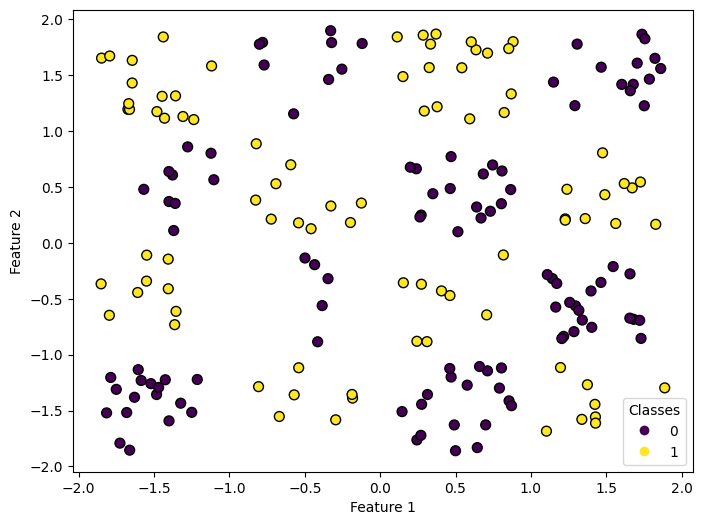

In [ ]:
# Generate the data
X_train, y_train = generate_grid_data(random_state=0)
X_test, y_test = generate_grid_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)

100%|██████████| 300/300 [00:04<00:00, 70.62it/s]


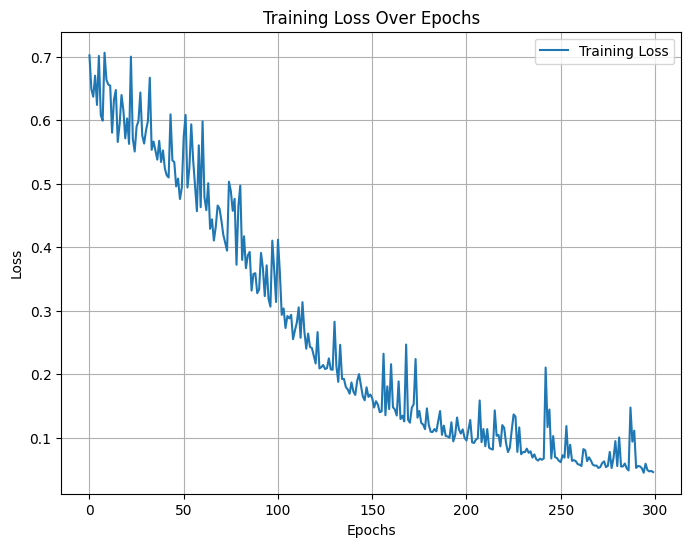

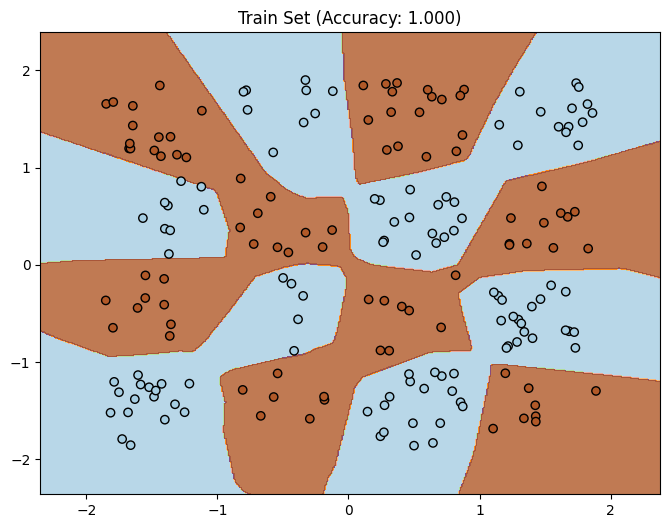

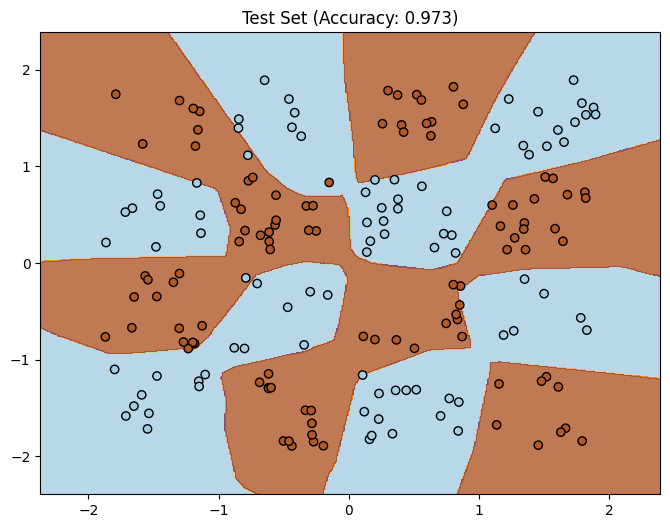

In [ ]:
### Your code goes here ####
train_loader, device = preprocess_data(X_train, y_train)
test_loader, _ = preprocess_data(X_test, y_test)

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=300)

plot_training_loss(train_losses)


train_accuracy = evaluate_model(model, train_loader, device)
plot_decision_boundaries(model, X_train, y_train, device, title=f"Train Set (Accuracy: {train_accuracy:.3f})")


test_accuracy = evaluate_model(model, test_loader, device)
plot_decision_boundaries(model, X_test, y_test, device, title=f"Test Set (Accuracy: {test_accuracy:.3f})")

The problem here isnt linear, here we tried at first 1 layer of NN with 16 hidden units, and learning rate at 0.01 and it was really bad (0.4 accuracy on test), we thought that the lr was too high and we needed one more hidden layer and we also added each layer to have 32 units, we played abit with the lr until we were satisfied with lr = 0.002

## EX3

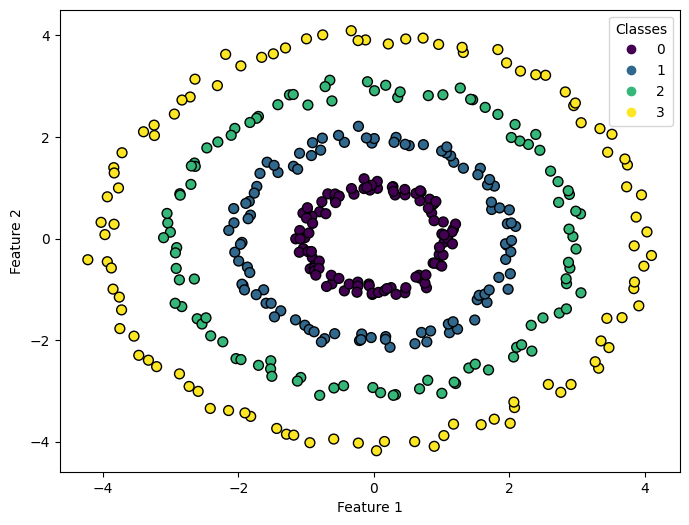

In [ ]:
# Generate the data
X_train, y_train = generate_concentric_circles_data(random_state=0)
X_test, y_test = generate_concentric_circles_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)


100%|██████████| 300/300 [00:06<00:00, 42.89it/s]


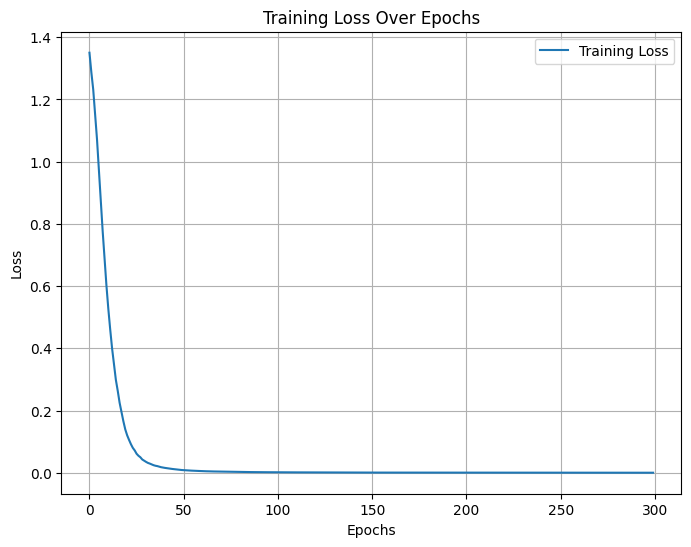

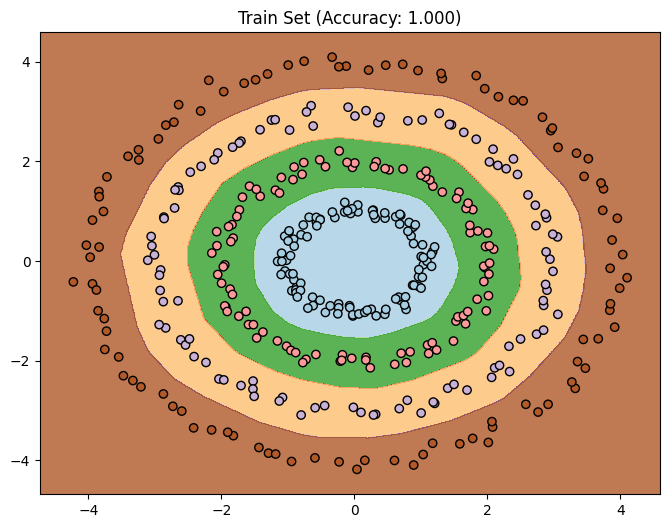

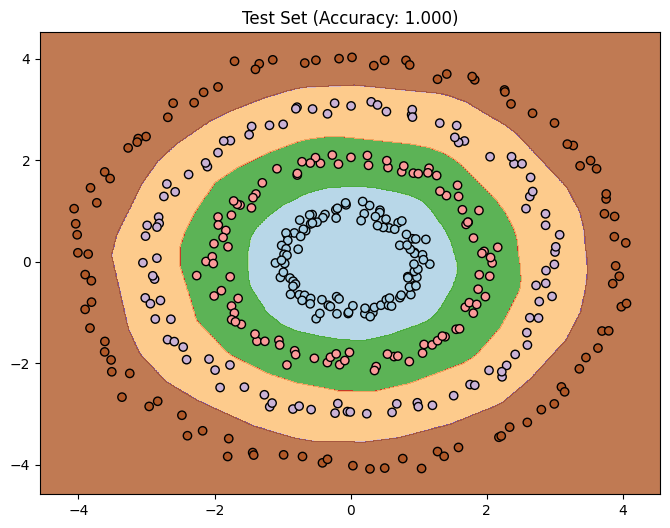

In [ ]:
### Your code goes here ####
train_loader, device = preprocess_data(X_train, y_train)
test_loader, _ = preprocess_data(X_test, y_test)

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 4)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=300)

plot_training_loss(train_losses)


train_accuracy = evaluate_model(model, train_loader, device)
plot_decision_boundaries(model, X_train, y_train, device, title=f"Train Set (Accuracy: {train_accuracy:.3f})")


test_accuracy = evaluate_model(model, test_loader, device)
plot_decision_boundaries(model, X_test, y_test, device, title=f"Test Set (Accuracy: {test_accuracy:.3f})")

here we used the same model architechture from last problem but we had 4 classes, so we changed the ouput to 4 and everything worked out fine, note that here we could use a linear model but we had to processes the data differently, to make our input shaped 1 by getting the l2 norm of the points (sqrt(x^2 + y^2))

## EX4

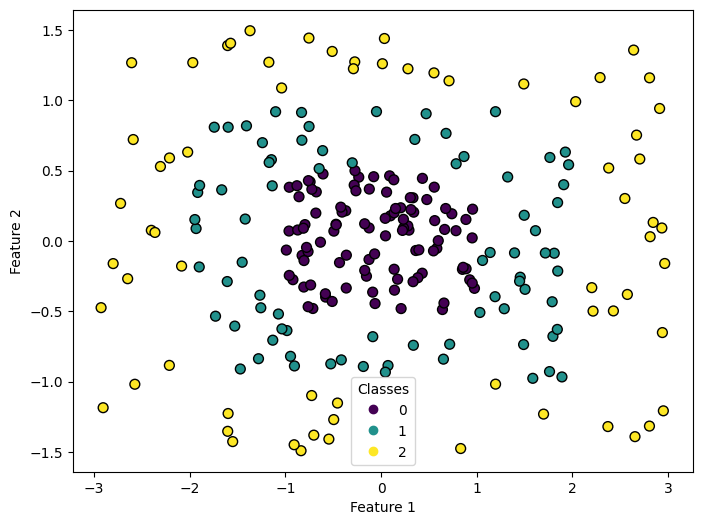

In [ ]:


# Generate the data
X_train, y_train = generate_nested_rectangles_data(random_state=0)
X_test, y_test = generate_nested_rectangles_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)

100%|██████████| 175/175 [00:02<00:00, 70.42it/s]


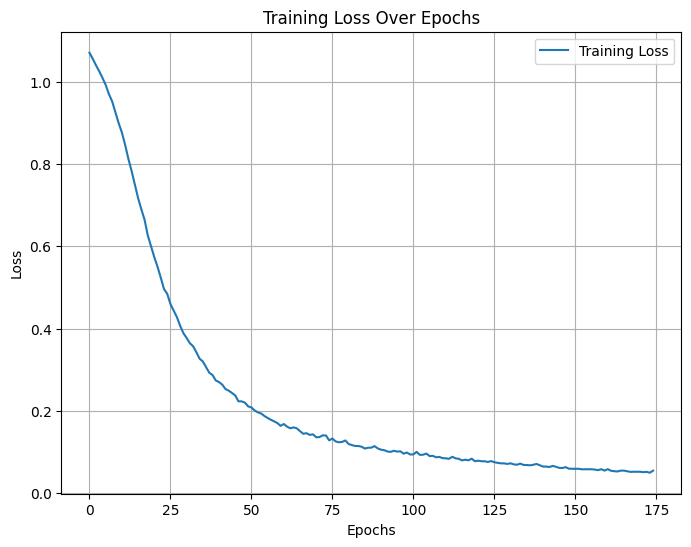

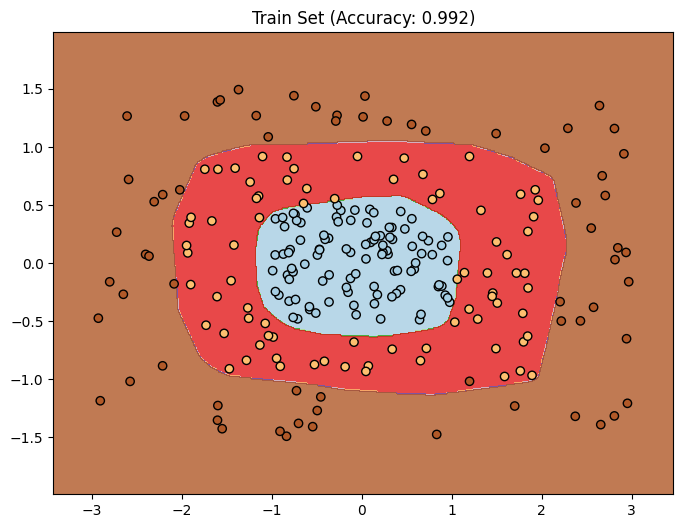

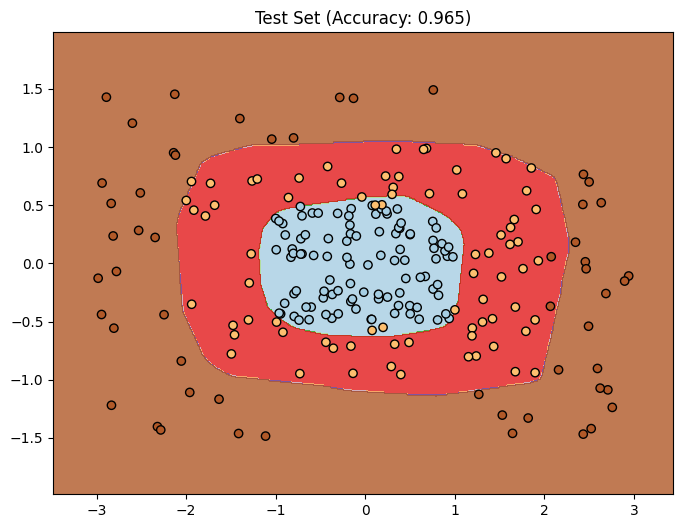

In [ ]:
### Your code goes here ####
train_loader, device = preprocess_data(X_train, y_train)
test_loader, _ = preprocess_data(X_test, y_test)

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=175)

plot_training_loss(train_losses)


train_accuracy = evaluate_model(model, train_loader, device)
plot_decision_boundaries(model, X_train, y_train, device, title=f"Train Set (Accuracy: {train_accuracy:.3f})")


test_accuracy = evaluate_model(model, test_loader, device)
plot_decision_boundaries(model, X_test, y_test, device, title=f"Test Set (Accuracy: {test_accuracy:.3f})")


the problem seems close to the spheres problem, so we used simmilar net from the last ex

## EX5 - Mystery Dataset
Load the data from the ex5.zip file:
X_train.npy
y_train.npy
X_test.npy
y_test.npy

Figure out the input and output dims and perform the classification task as in previous exercises.

You do not have to plot the data, but you may if you see fit.

In [ ]:
## load numpy array using np.load()
X_train, y_train, X_test, y_test = np.load("./X_train.npy"), np.load("./y_train.npy"), np.load("./X_test.npy"), np.load("./y_test.npy")
input_shape = X_train.shape[1] if len(X_train.shape) > 1  else 1
output_shape = len(set(y_train))
print(input_shape, output_shape)

5 6


100%|██████████| 100/100 [00:03<00:00, 25.13it/s]


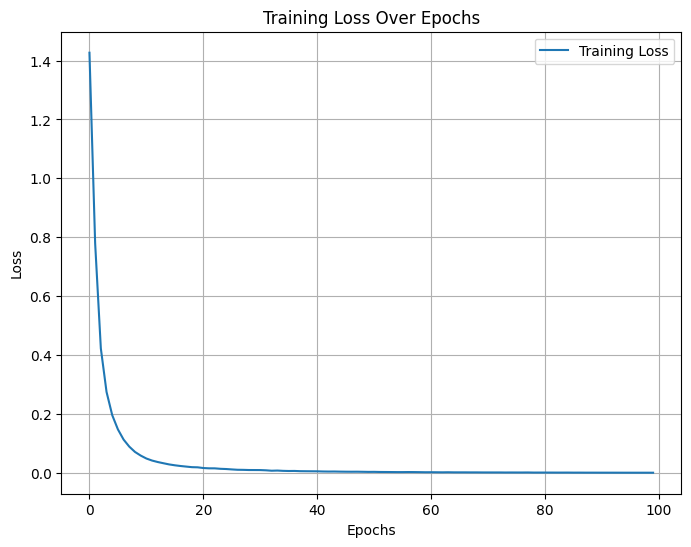

Train Set (Accuracy: 1.000)
Test Set (Accuracy: 0.983)


In [ ]:

### Your code goes here ####
train_loader, device = preprocess_data(X_train, y_train)
test_loader, _ = preprocess_data(X_test, y_test)

model = nn.Sequential(
    nn.Linear(input_shape, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, output_shape)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=100)

plot_training_loss(train_losses)

train_accuracy = evaluate_model(model, train_loader, device)
test_accuracy = evaluate_model(model, test_loader, device)

print(f"Train Set (Accuracy: {train_accuracy:.3f})")
print(f"Test Set (Accuracy: {test_accuracy:.3f})")



we got the shape from the input, and the number of classes to classify from the different values of y, and put it in a nn.

#Section 2: Regression Tasks
In this section your task is to predict the value of each point (indicated by the color in the scatter plots) using it's coordinates.
## TODO
For the entire section, do the following (i.e., only once):
1. Use the training function from previous section.
2. Use the plotting function from previous section to plot the loss.
3. Use the provided plotting function to plot the data with your predicted label values. For instance:


```
plot_s_curve(X_train, y_train_pred)
```


4. Write a preprocessing function for the inputs (convert to torch tensor, etc).
5. Write an evaluation function that prints the set Mean Square Error (train/test).

For each of the 3 exercises, do the following:
1. Create an MLP using PyTorch.
2. Train the model and plot the loss across epochs.
3. Plot the predicted values for the train set. Show the MSE in the title (up to 3 decimals points).
4. Plot the predicted values for the test set. Show the MSE in the title (up to 3 decimals points).
5. Create a Markdown cell and explain briefly (2-3 lines): why did the model perform well/poorly? What affected your design choices?

**Grading**: in this section you are only graded on the correctness of your code and discussion.

**Optional**: you may want to plot the residuals between your model prediction and the true labels. For instance, you may plot the data and use the differences between the true and predicted labels as their color.

## Setup

In [ ]:
from sklearn.datasets import make_s_curve
### EX7
def generate_s_curve_data(n_samples=150, random_state=42):
    X, t = make_s_curve(n_samples, random_state=random_state)
    X = X[:, [0, 2]]  # Use only 2D input (X[:, 0] and X[:, 2])
    return X, t

def create_labels_s_curve(X, t):
    # Sort the indices based on the S-curve parameter t
    sorted_indices = np.argsort(t)
    labels = np.linspace(-1, 1, len(t))
    y = np.zeros_like(t)
    y[sorted_indices] = labels
    return y

def plot_s_curve(X, y, title='S-Curve'):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.colorbar(scatter, label='Label')
    plt.show()


### EX8
def generate_spiral_data(n_points=1000, n_turns=2.5, noise=0.05, random_state=42):
    np.random.seed(random_state)
    theta = np.linspace(0, n_turns * 2 * np.pi, n_points)
    r = np.linspace(0, 1, n_points)
    x = r * np.cos(theta) + noise * np.random.randn(n_points)
    y = r * np.sin(theta) + noise * np.random.randn(n_points)
    X = np.vstack((x, y)).T
    return X, theta

def create_labels_spiral(theta):
    labels = np.linspace(-1, 1, len(theta))
    return labels

def plot_spiral(X, y, title='Spiral'):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.colorbar(scatter, label='Label')
    plt.show()

### EX9
def generate_spiral_data_3d(n_points=1000, n_turns=2.5, noise=0.05, random_state=42):
    np.random.seed(random_state)
    theta = np.linspace(0, n_turns * 2 * np.pi, n_points)
    z = np.linspace(0, 1, n_points)
    r = z
    x = r * np.cos(theta) + noise * np.random.randn(n_points)
    y = r * np.sin(theta) + noise * np.random.randn(n_points)
    X = np.vstack((x, y, z)).T
    return X, theta

def create_labels_3d_spiral(theta):
    labels = np.linspace(-1, 1, len(theta))
    return labels

def plot_spiral_3d(X, y, title='3D Spiral'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', edgecolor='k')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label='Label')
    plt.show()

## TODO - You general functions for Section 2

In [ ]:
### Your code goes here ###
### Imports
import torch.nn.functional as F
### Preprocessing function ####
def preprocess_data_reg(X, y, batch_size=32):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_tensor = torch.tensor(X).to(device).float()
    y_tensor = torch.tensor(y).to(device).float()
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), device
### Evaluation function ###


def evaluate_mse(model, X_train, y_train, X_test, y_test):
    model.eval()


    with torch.no_grad():

        y_train_pred = model(X_train)
        y_test_pred = model(X_test)


        y_train_pred = y_train_pred.squeeze()
        y_test_pred = y_test_pred.squeeze()

        mse_train = F.mse_loss(y_train_pred, y_train).item()
        mse_test = F.mse_loss(y_test_pred, y_test).item()


    print(f"Mean Square Error (Train): {mse_train:.4f}")
    print(f"Mean Square Error (Test): {mse_test:.4f}")


    return y_train_pred.detach().cpu().numpy(), y_test_pred.detach().cpu().numpy()

def train_model(model, train_loader, criterion, optimizer, device, epochs=100):

  model.to(device)
  train_losses = []
  for epoch in tqdm(range(epochs)):
      model.train()
      epoch_loss = 0.0
      for X_batch, y_batch in train_loader:
          optimizer.zero_grad()
          outputs = model(X_batch).squeeze()
          loss = criterion(outputs, y_batch)
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()
      train_losses.append(epoch_loss / len(train_loader))
  return model, train_losses

  ### Additional plotting functions ###

## EX6

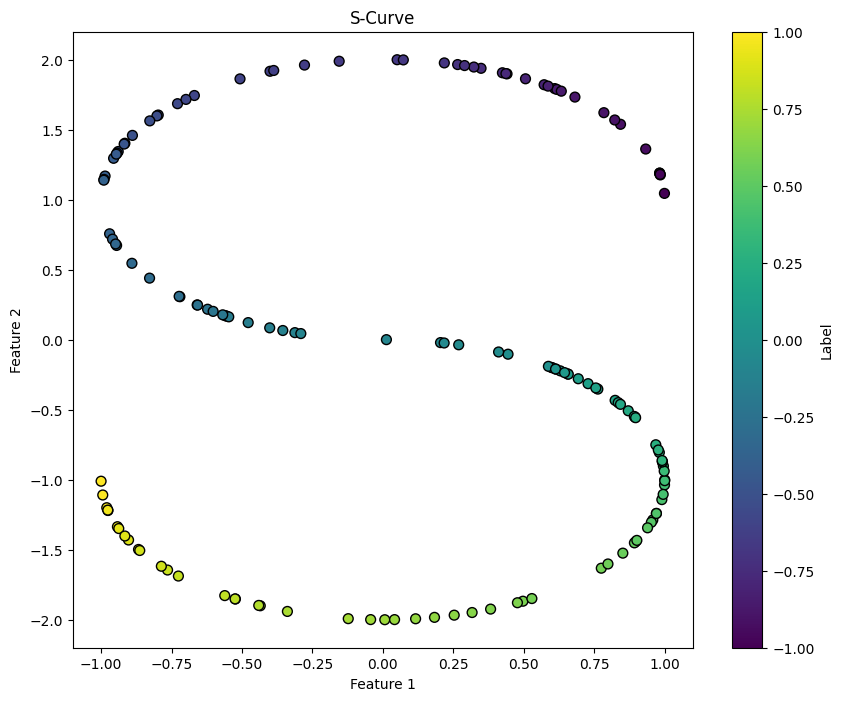

In [ ]:
# Generate the data
X_train, theta_train = generate_s_curve_data(random_state=0)
X_test, theta_test = generate_s_curve_data(random_state=1)
# Create the labels
y_train = create_labels_s_curve(X_train, theta_train)
y_test = create_labels_s_curve(X_test, theta_test)
# Plot the data
plot_s_curve(X_train, y_train)

100%|██████████| 400/400 [00:03<00:00, 107.29it/s]


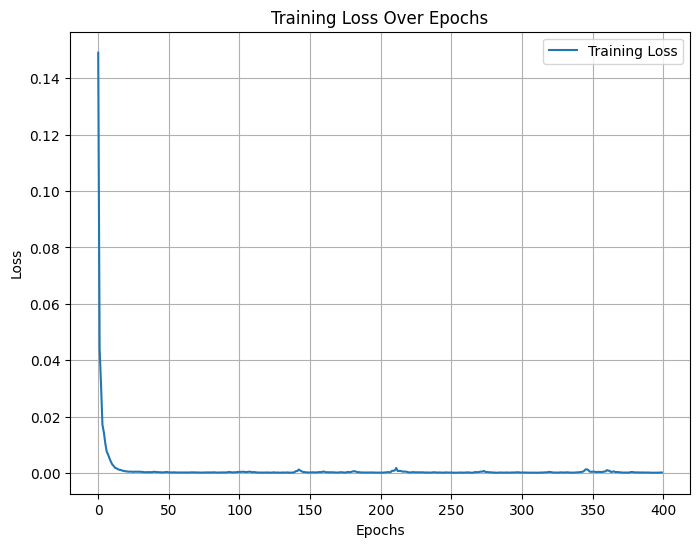

Mean Square Error (Train): 0.0001
Mean Square Error (Test): 0.0103


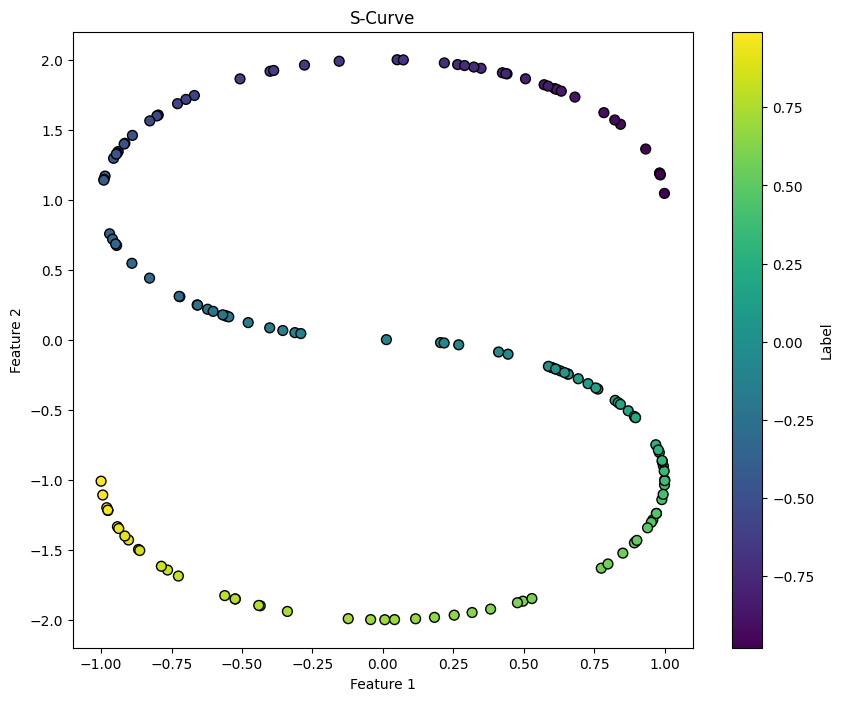

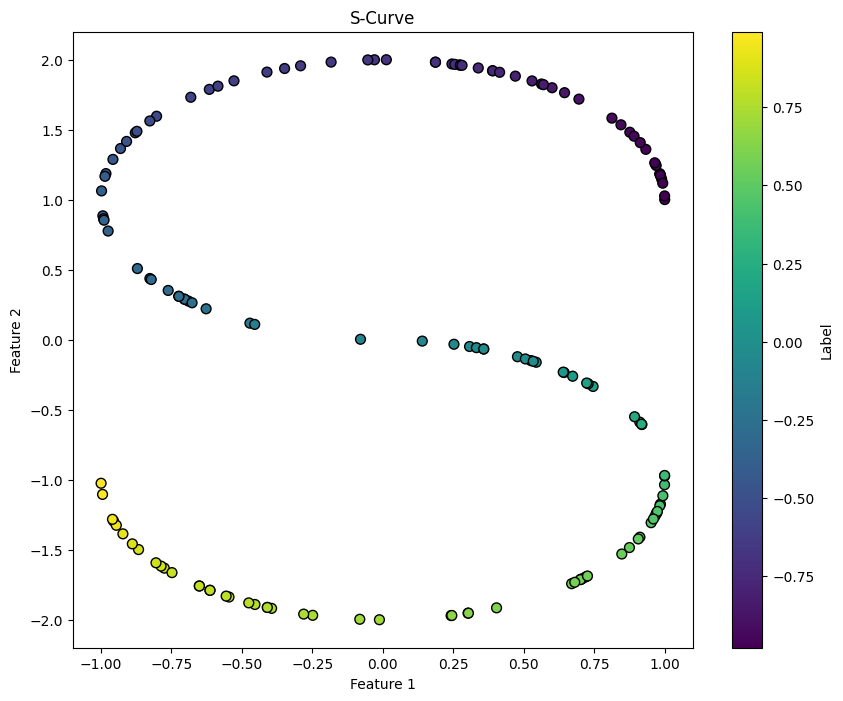

In [ ]:
### Your code goes here ####
train_loader, device = preprocess_data_reg(X_train, y_train)
test_loader, _ = preprocess_data_reg(X_test, y_test)

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=400)

plot_training_loss(train_losses)

X_tensor_train = torch.tensor(X_train).to(device).float()
y_tensor_train = torch.tensor(y_train).to(device).float()

X_tensor_test = torch.tensor(X_test).to(device).float()
y_tensor_test = torch.tensor(y_test).to(device).float()


evaluate_mse(model, X_tensor_train, y_tensor_train, X_tensor_test, y_tensor_test)

y_train_pred, y_test_pred = model(X_tensor_train), model(X_tensor_test)
y_train_pred, y_test_pred = y_train_pred.squeeze(), y_test_pred.squeeze()

plot_s_curve(X_train, y_train_pred.detach().numpy())
plot_s_curve(X_test, y_test_pred.detach().numpy())


## EX7

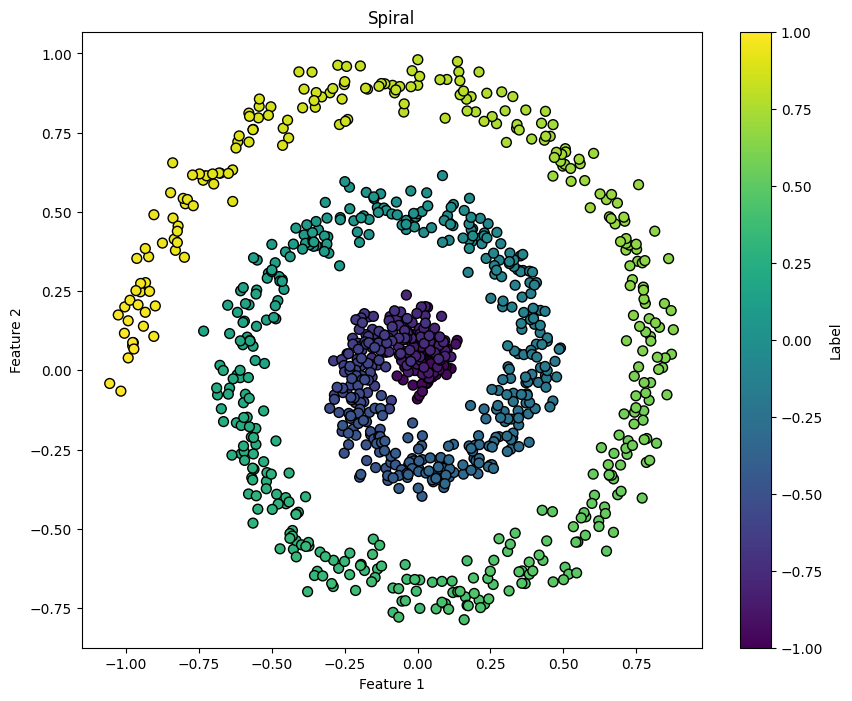

In [ ]:
# Generate the data
X_train, theta_train = generate_spiral_data(random_state=0)
X_test, theta_test = generate_spiral_data(random_state=1)
# Create the labels
y_train = create_labels_spiral(theta_train)
y_test = create_labels_spiral(theta_test)
# Plot the data
plot_spiral(X_train, y_train)


100%|██████████| 400/400 [00:32<00:00, 12.32it/s]


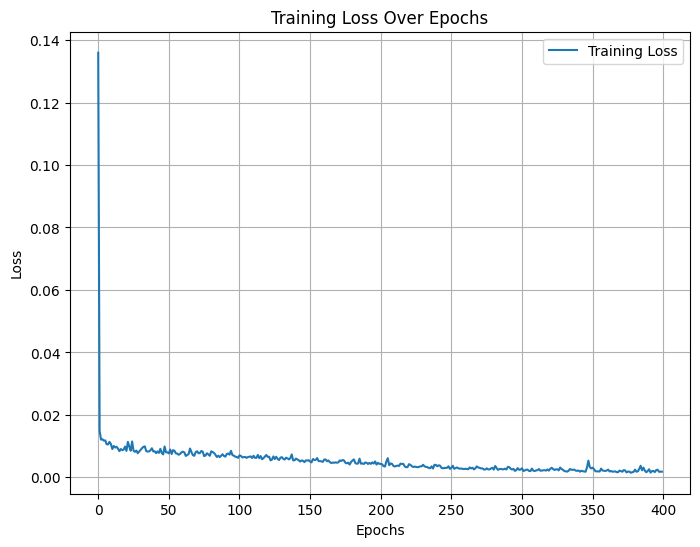

Mean Square Error (Train): 0.0014
Mean Square Error (Test): 0.0029


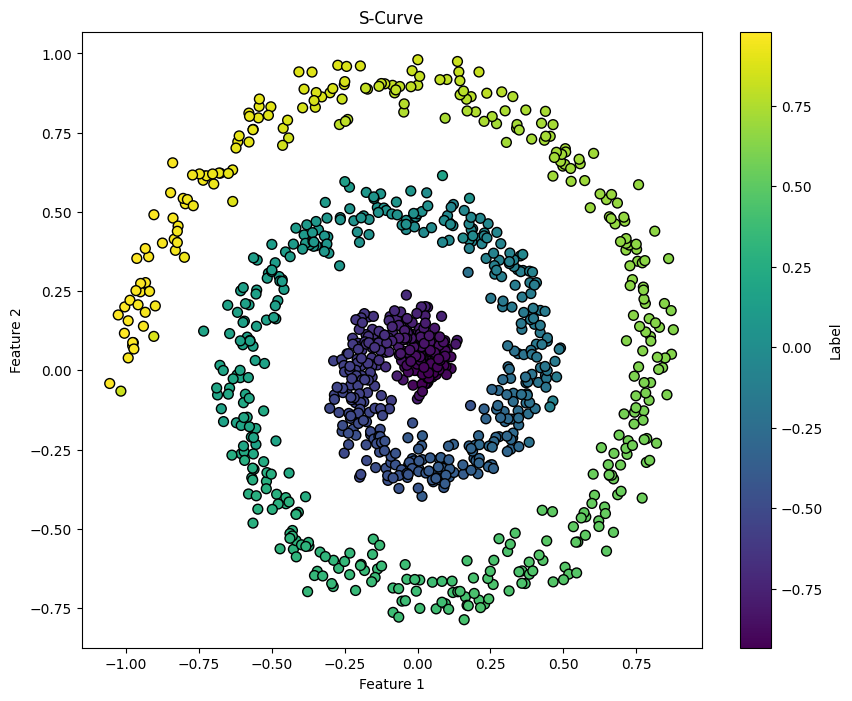

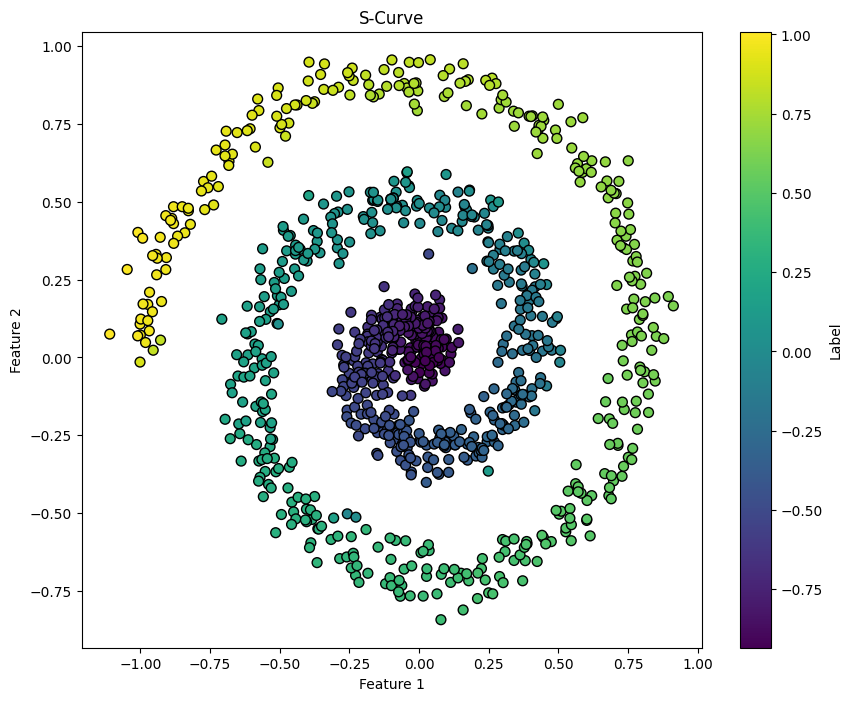

In [ ]:

train_loader, device = preprocess_data_reg(X_train, y_train)
test_loader, _ = preprocess_data_reg(X_test, y_test)

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=400)

plot_training_loss(train_losses)

X_tensor_train = torch.tensor(X_train).to(device).float()
y_tensor_train = torch.tensor(y_train).to(device).float()

X_tensor_test = torch.tensor(X_test).to(device).float()
y_tensor_test = torch.tensor(y_test).to(device).float()


evaluate_mse(model, X_tensor_train, y_tensor_train, X_tensor_test, y_tensor_test)

y_train_pred, y_test_pred = model(X_tensor_train), model(X_tensor_test)
y_train_pred, y_test_pred = y_train_pred.squeeze(), y_test_pred.squeeze()

plot_s_curve(X_train, y_train_pred.detach().numpy())
plot_s_curve(X_test, y_test_pred.detach().numpy())


## EX8

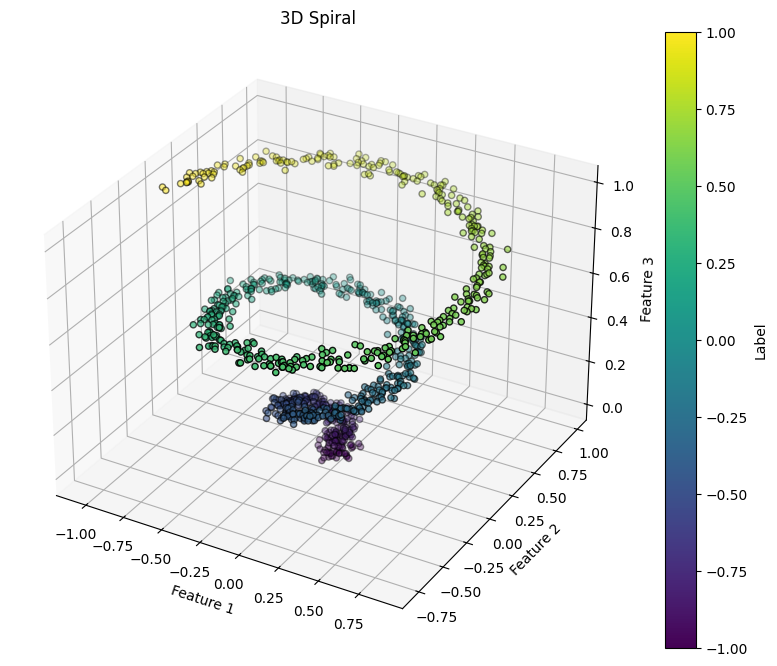

100%|██████████| 400/400 [00:25<00:00, 15.78it/s]


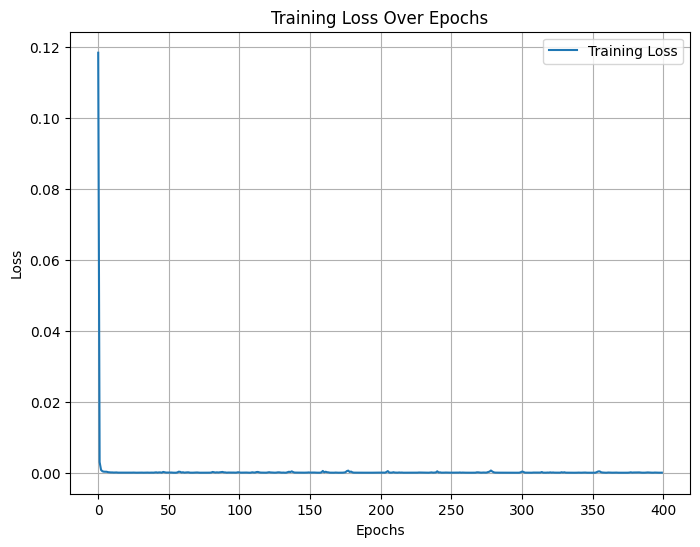

Mean Square Error (Train): 0.0000
Mean Square Error (Test): 0.0000


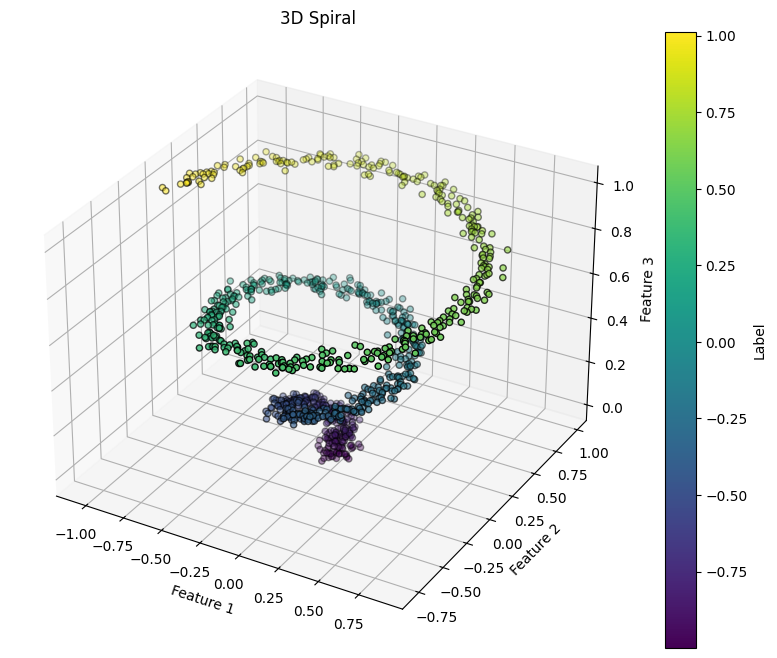

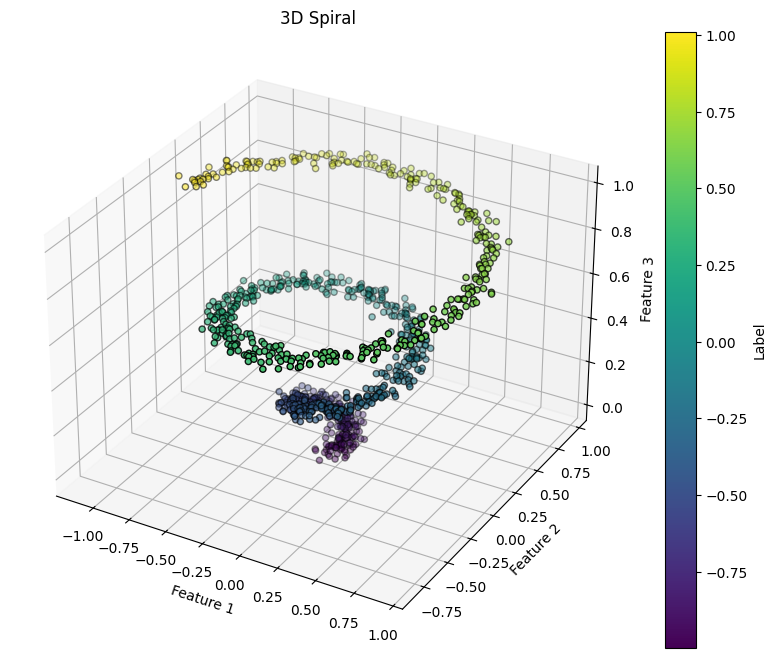

In [ ]:
# Generate the data
X_train, theta_train = generate_spiral_data_3d(random_state=0)
X_test, theta_test = generate_spiral_data_3d(random_state=1)

# Create the labels
y_train = create_labels_3d_spiral(theta_train)
y_test = create_labels_3d_spiral(theta_test)

# Plot the data
plot_spiral_3d(X_train, y_train)

### Your code goes here ####
train_loader, device = preprocess_data_reg(X_train, y_train)
test_loader, _ = preprocess_data_reg(X_test, y_test)

model = nn.Sequential(
    nn.Linear(3, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model, train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=400)

plot_training_loss(train_losses)

X_tensor_train = torch.tensor(X_train).to(device).float()
y_tensor_train = torch.tensor(y_train).to(device).float()

X_tensor_test = torch.tensor(X_test).to(device).float()
y_tensor_test = torch.tensor(y_test).to(device).float()


evaluate_mse(model, X_tensor_train, y_tensor_train, X_tensor_test, y_tensor_test)

y_train_pred, y_test_pred = model(X_tensor_train), model(X_tensor_test)
y_train_pred, y_test_pred = y_train_pred.squeeze(), y_test_pred.squeeze()

plot_spiral_3d(X_train, y_train_pred.detach().numpy())
plot_spiral_3d(X_test, y_test_pred.detach().numpy())


# MNIST Binary Classification Task (20 pts.)
## EX9
Perform a binray classification task on the MNIST dataset between two digits (you may choose any two digits).
### You are required to do the following:
1. Create a subset of the train/test sets for the two digits you have chosen
2. Create a validation set out of the train set (80%-20% split)
3. Normalize the data
4. Write a training function
5. Write an evaluation function that returns the accuracy
6. Plot the training and validation accuracy for each epoch
7. Plot 10 test images of each class with their predicited labels
8. Print the test set accuracy

### Hyperparameters:
Briefly explain why you have chosen each parameter:
1. Model: MLP, CNN (both are valid options)
2. Number of layers, number of neurons/kernels, kernel size
3. Number of epochs (between 10-100)
4. Learning rate
5. Loss function
6. Activation function

**Grading**: Correctness and discussion. You are not grade on accuracy in this section.

### Discuss the results (3-5 lines)
Did the model converge? did it overfit? How is classifying images different from the toy examples we saw? Write you overall first impressions after solving this HW.

For this Task we chose a cnn model for its power to indentify patterns in 2d data, we used the model presented to us in the tirgul. we used 64 kernels with size of 3 as used in the tirgul, num of epochs was 20- our data-set is large 12000 images so we didnt need as much of epochs, we used learning rate of 0.1- started with it and got great results so we continued with it, and the loss function we used CrossEntropyLoss for classification, we also tried BCELoss and achieved the same results in the acurracy, the activation function was Relu when we were in the CrossEntropyLoss and sigmoid when we used BCELoss. the model converge, it didnt overfit becuase the test accuracy and validation was also very high, in classfing images we need to have more complex model and vast dataset to indentify patterns, in the toy examples it was really easy to the model to predict right, overall it was fun to experminet with the NN and to achive good resluts overall Nice Work :)

In [ ]:
import numpy as np
import torch
from torch import nn
from torch import optim
import torchvision
from torchvision import transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, SubsetRandomSampler
from tqdm.auto import tqdm
from torch.utils.data import random_split
from torchsummary import summary


In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2, num_filters=[64, 64], input_dims=(1,28,28)):
        super(CNN, self).__init__()
        # Define convolutional layers
        self.conv1 = nn.Conv2d(
            in_channels=in_channels, out_channels=num_filters[0], kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(
            in_channels=num_filters[0], out_channels=num_filters[1], kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Compute the flatten dimension dynamically
        self.flatten_dim = self._get_conv_output(input_dims)

        # Define fully connected layers
        self.fc1 = nn.Linear(self.flatten_dim, 32)
        self.fc2 = nn.Linear(32, num_classes)  # MNIST has 10 classes

    def _get_conv_output(self, shape):
        """
        Computes the size of the flattened features after the convolutional layers.

        Parameters:
        - shape: Tuple representing the shape of the input image (channels, height, width).

        Returns:
        - n_size: The size of the flattened features.
        """
        with torch.no_grad():
            batch_size = 1
            input = torch.rand(batch_size, *shape)
            output_feat = self._forward_features(input)
            n_size = output_feat.view(batch_size, -1).shape[1]
        return n_size

    def _forward_features(self, x):
        """
        Forward pass through convolutional layers.

        Parameters:
        - x: Input tensor.

        Returns:
        - x: Output tensor after convolutional and pooling layers.
        """
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        return x

    def forward(self, x):
        """
        Forward pass through the network.

        Parameters:
        - x: Input tensor.

        Returns:
        - x: Output tensor after passing through the network.
        """
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Define training function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=100):
    model.to(device)
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in tqdm(range(epochs)):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                # Calculate accuracy
                predicted = torch.argmax(outputs, dim=1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total)

    return model, train_losses, val_losses, val_accuracies

# Define evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total
    return accuracy, predicted, y_batch, X_batch

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.14MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



  0%|          | 0/20 [00:00<?, ?it/s]

Test Accuracy: 0.9981


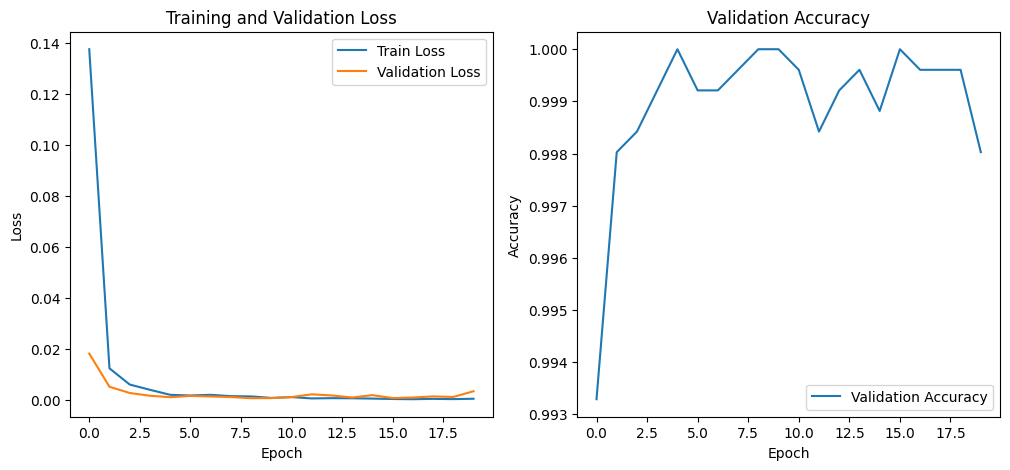

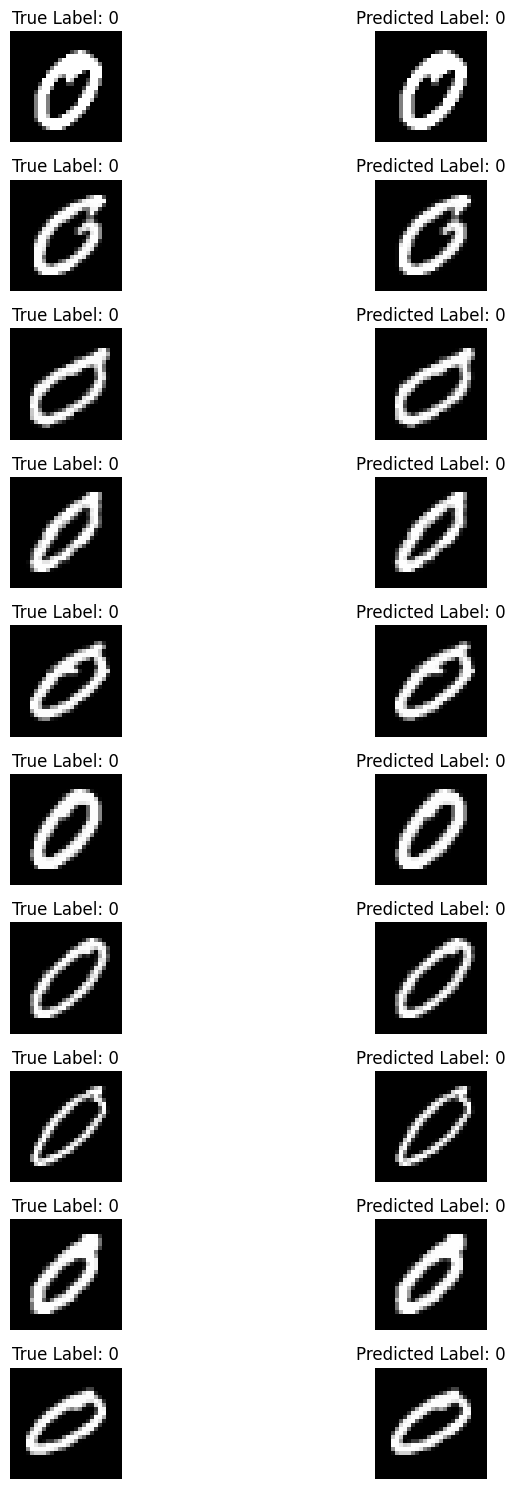

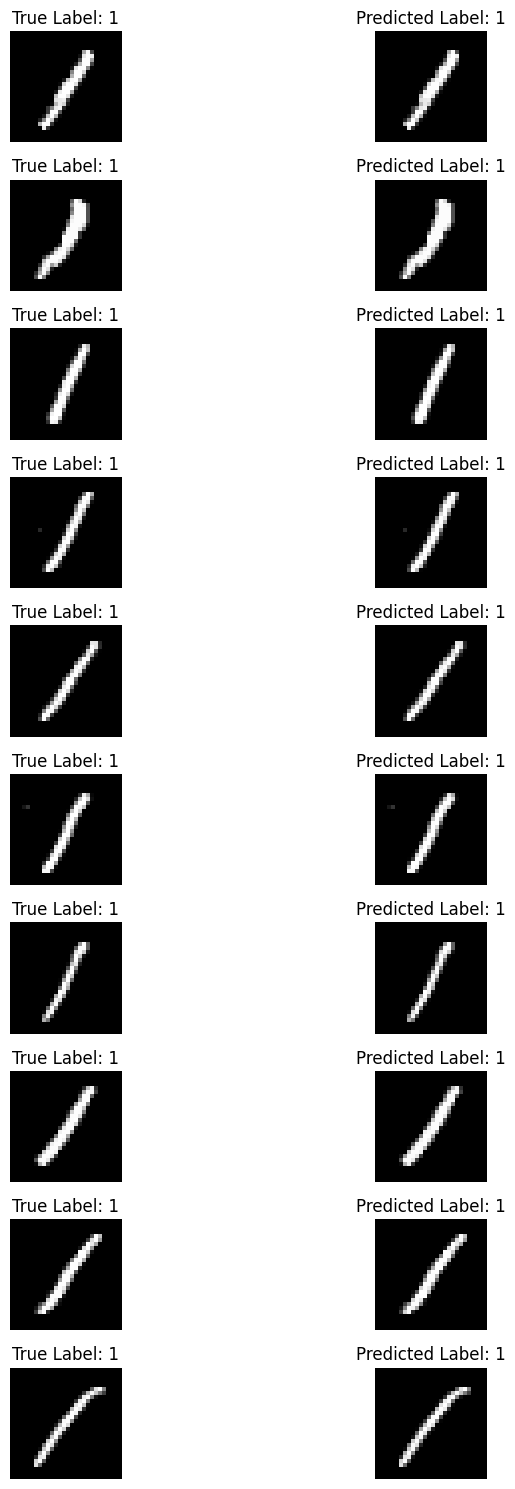

In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Load the MNIST dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Filter dataset for two digits (e.g., 0 and 1)
def filter_digits(dataset, digits):
    indices = [i for i, label in enumerate(dataset.targets) if label in digits]
    dataset.targets = dataset.targets[indices]
    dataset.data = dataset.data[indices]
    return dataset

trainset = filter_digits(trainset, digits=[0, 1])
testset = filter_digits(testset, digits=[0, 1])

# Create validation split (80% train, 20% validation)
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = torch.utils.data.random_split(trainset, [train_size, val_size])

# Create DataLoaders
batch_size = 512  # Update batch size as per requirement
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

# Model, criterion, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN(in_channels=1, num_classes=2)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=20)


test_accuracy, predicted, y_batch, X_batch = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_accuracy:.4f}")


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')


plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Validation Accuracy')

plt.show()

# Plot 10 test images of each class with predicted labels
def plot_test_images(images, labels, predictions, num_images=10):
    fig, axes = plt.subplots(num_images, 2, figsize=(10, 15))
    for i in range(num_images):
        axes[i, 0].imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
        axes[i, 0].set_title(f"True Label: {labels[i].item()}")
        axes[i, 1].imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
        axes[i, 1].set_title(f"Predicted Label: {predictions[i].item()}")
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

# Plot 10 images of each class
class_0_indices = (y_batch == 0).nonzero().squeeze()
class_1_indices = (y_batch == 1).nonzero().squeeze()

# Get 10 images from each class
class_0_images = X_batch[class_0_indices][:10]
class_1_images = X_batch[class_1_indices][:10]
class_0_labels = y_batch[class_0_indices][:10]
class_1_labels = y_batch[class_1_indices][:10]
class_0_preds = predicted[class_0_indices][:10]
class_1_preds = predicted[class_1_indices][:10]

# Plot images
plot_test_images(class_0_images, class_0_labels, class_0_preds)
plot_test_images(class_1_images, class_1_labels, class_1_preds)